<a href="https://colab.research.google.com/github/SalmanOkz/computer_vision/blob/main/cv_lab_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - accuracy: 0.7945 - loss: 0.5754 - val_accuracy: 0.8813 - val_loss: 0.3342
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.8988 - loss: 0.2816 - val_accuracy: 0.8986 - val_loss: 0.2775
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8998 - loss: 0.2831
Test Accuracy: 0.8985999822616577


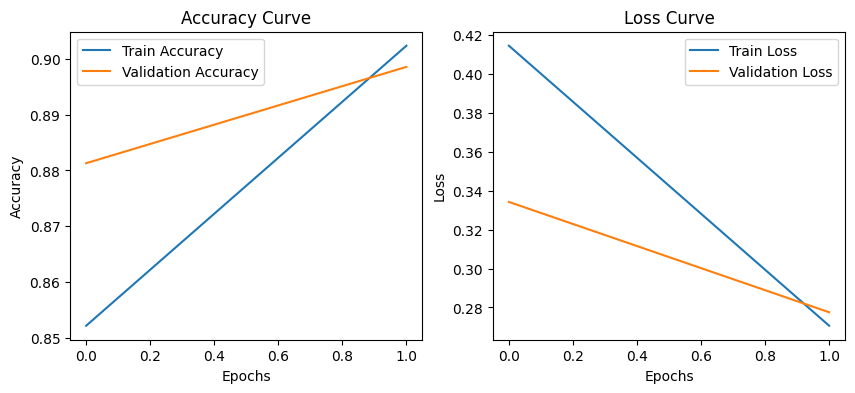

In [1]:
# Import Libraries
from tensorflow.keras import datasets, models, layers
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# 2. Reshape & Normalize
x_train = x_train.reshape(-1,28,28,1).astype('float32')/255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32')/255.0

# 3. Build CNN
model = models.Sequential([
    # Conv Layer with padding='same' (preserve input size)
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    # MaxPooling layer (reduces feature map size)
    layers.MaxPooling2D(pool_size=(2,2)),

    # Second Conv Layer
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten to 1D
    layers.Flatten(),
    # Fully Connected Layer
    layers.Dense(64, activation='relu'),
    # Output Layer
    layers.Dense(10, activation='softmax')
])

# 4. Compile Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Train Model (2 epochs for demo)
history = model.fit(x_train, y_train, epochs=2, validation_data=(x_test, y_test))

# 6. Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# 7. Plot Accuracy & Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()